<a href="https://colab.research.google.com/github/eliasrbarbour/AAI614_eliasbarbour/blob/main/DS_EliasBarbour_Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AAI614 – Project 1: Income Patterns in the 1994 US Census (Adult Dataset)

**Student:** Elias Barbour

Data: UCI Adult dataset (Kohavi & Becker, 1996), loaded with the `ucimlrepo` package. This version combines the original training file (32,561 rows) and test file (16,281 rows), for 48,842 rows in total.

## Setup

In [1]:
!pip install -q ucimlrepo

import pandas as pd                      # data tables
import numpy as np                       # numeric tools and np.nan
import matplotlib.pyplot as plt          # plots
from scipy import stats                  # statistical tests
import statsmodels.formula.api as smf    # regression models
from statsmodels.stats.anova import anova_lm   # F-test to compare nested models
from ucimlrepo import fetch_ucirepo      # downloads datasets from the UCI repository

## Data Loading

In [2]:
adult = fetch_ucirepo(id=2)              # download the Adult dataset (id=2 on UCI)
X = adult.data.features                  # the 14 input columns
y = adult.data.targets                   # the income column

df = pd.concat([X, y], axis=1)                              # join features and income side by side
df.columns = df.columns.str.replace("-", "_")               # education-num -> education_num
df = df.rename(columns={"income": "gross_income_group"})    # rename to match the assignment

print(df.shape)                          # (rows, columns)
df.head()

(48842, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,gross_income_group
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


# Data Exploration

## Q1. Check the columns of your data. Are they the expected data types based on their descriptions?

In [3]:
# Expected types from the dataset description
check = adult.variables[["name", "type"]].copy()

# Match the names to our renamed columns
check["name"] = check["name"].str.replace("-", "_").replace({"income": "gross_income_group"})

# Actual types loaded by pandas, next to the expected ones
check["pandas_dtype"] = check["name"].map(df.dtypes.astype(str))
check

,name,type,pandas_dtype
0,age,Integer,int64
1,workclass,Categorical,object
2,fnlwgt,Integer,int64
3,education,Categorical,object
4,education_num,Integer,int64
5,marital_status,Categorical,object
6,occupation,Categorical,object
7,relationship,Categorical,object
8,race,Categorical,object
9,sex,Binary,object


In [4]:
# Check the values of the two binary columns (binary = exactly 2 values)
print(df["sex"].value_counts(), "\n")
print(df["gross_income_group"].value_counts())

sex
Male      32650
Female    16192
Name: count, dtype: int64 

gross_income_group
<=50K     24720
<=50K.    12435
>50K       7841
>50K.      3846
Name: count, dtype: int64


In [5]:
# Remove the trailing period from the test-file labels ("<=50K." -> "<=50K")
df["gross_income_group"] = df["gross_income_group"].str.rstrip(".")
df["gross_income_group"].value_counts()

,count
gross_income_group,
<=50K,37155
>50K,11687


**Answer:** All six integer columns (`age`, `fnlwgt`, `education_num`, `capital_gain`, `capital_loss`, `hours_per_week`) were loaded as `int64`, and all categorical and binary columns were loaded as `object` (text), so the data types match the dataset description. However, checking the values of the two binary columns showed a problem: `sex` has the expected two values, but `gross_income_group` had four: `<=50K`, `>50K`, `<=50K.` and `>50K.`. The labels with a trailing period come from the test file (16,281 rows), which is combined with the training file (32,561 rows) to give the full 48,842 rows. I removed the trailing period with `str.rstrip(".")`, which leaves two values: `<=50K` (37,155 rows) and `>50K` (11,687 rows). I also noticed that `education` and `education_num` carry the same information, since `education_num` is a numeric code for the education level.

## Q2. How are missing values represented in this data? Cast missing values to np.nan, if necessary. Count the number of missing values in each column.

In [6]:
# Which columns the dataset description says have missing values
adult.variables[["name", "missing_values"]]

,name,missing_values
0,age,no
1,workclass,yes
2,fnlwgt,no
3,education,no
4,education-num,no
5,marital-status,no
6,occupation,yes
7,relationship,no
8,race,no
9,sex,no


In [7]:
# Count the values already stored as NaN in each column
df.isna().sum()

,0
age,0
workclass,963
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,966
relationship,0
race,0
sex,0


In [8]:
# Keep only the text columns, since "?" can only appear in text
obj = df.select_dtypes(exclude="number")

# For each column: remove spaces, mark cells equal to "?", then count them
obj.apply(lambda s: s.str.strip().eq("?")).sum()

,0
workclass,1836
education,0
marital_status,0
occupation,1843
relationship,0
race,0
sex,0
native_country,583
gross_income_group,0


In [9]:
# Replace any cell that contains only "?" (with or without spaces) by NaN
df = df.replace(r"^\s*\?\s*$", np.nan, regex=True)

# Number and percentage of missing values per column
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),                  # number of missing values
    "missing_pct": (df.isna().mean() * 100).round(2)   # share of missing values, in %
})

# Show only the columns that have at least one missing value
missing[missing["missing_count"] > 0]

,missing_count,missing_pct
workclass,2799,5.73
occupation,2809,5.75
native_country,857,1.75


In [10]:
# People with a missing occupation but a known workclass: which workclass are they?
df.loc[df["occupation"].isna() & df["workclass"].notna(), "workclass"].value_counts()

,count
workclass,
Never-worked,10


**Answer:** The dataset description lists three columns with missing values: `workclass`, `occupation` and `native_country`. In this data, missing values are represented in two different ways. Rows from the test file already have them as `NaN` (963 in `workclass`, 966 in `occupation`, 274 in `native_country`), while rows from the training file use the text `"?"` (1,836, 1,843 and 583). Because pandas treats `"?"` as a normal value, `isna()` alone would miss about two-thirds of the missing data. I replaced every `"?"` with `np.nan`, which gives these totals:

| Column | Missing | % of rows |
|---|---|---|
| workclass | 2,799 | 5.73% |
| occupation | 2,809 | 5.75% |
| native_country | 857 | 1.75% |

All other columns have no missing values. `occupation` has 10 more missing values than `workclass`. These 10 people have `workclass = Never-worked`, so for them occupation is not unknown but does not apply, which is a different kind of missing value from the rest.

## Q3. Individually plot the distributions of capital_gain and capital_loss. Should these variables be transformed into categorical variables?

In [11]:
# Summary of each variable: how many zeros, how many non-zero values, and the extremes
summary = pd.DataFrame({
    col: {
        "% zero": round((df[col] == 0).mean() * 100, 2),           # share of people with no gain/loss
        "non-zero count": int((df[col] > 0).sum()),               # people with a gain/loss
        "median of non-zero": df.loc[df[col] > 0, col].median(),  # typical size when not zero
        "max": df[col].max(),                                     # largest value
        "rows at max": int((df[col] == df[col].max()).sum()),     # how often the maximum appears
        "skewness": round(df[col].skew(), 2),                     # 0 = symmetric, >0 = long right tail
    }
    for col in ["capital_gain", "capital_loss"]
})
summary

,capital_gain,capital_loss
% zero,91.74,95.33
non-zero count,4035.00,2282.00
median of non-zero,7298.00,1887.00
max,99999.00,4356.00
rows at max,244.00,3.00
skewness,11.89,4.57


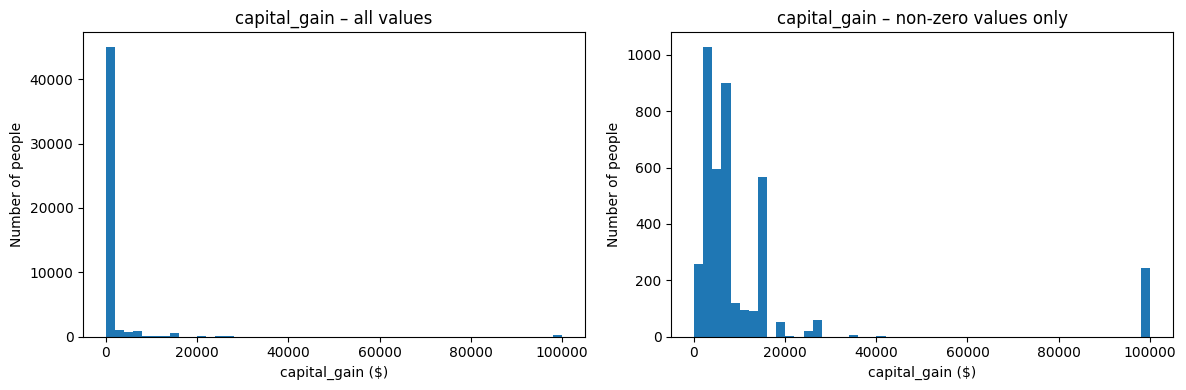

In [12]:
# capital_gain: all values (left) and only the non-zero values (right)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(df["capital_gain"], bins=50)                         # full distribution
ax[0].set_title("capital_gain – all values")
ax[0].set_xlabel("capital_gain ($)"); ax[0].set_ylabel("Number of people")

ax[1].hist(df.loc[df["capital_gain"] > 0, "capital_gain"], bins=50)   # zeros removed
ax[1].set_title("capital_gain – non-zero values only")
ax[1].set_xlabel("capital_gain ($)"); ax[1].set_ylabel("Number of people")

plt.tight_layout()
plt.show()

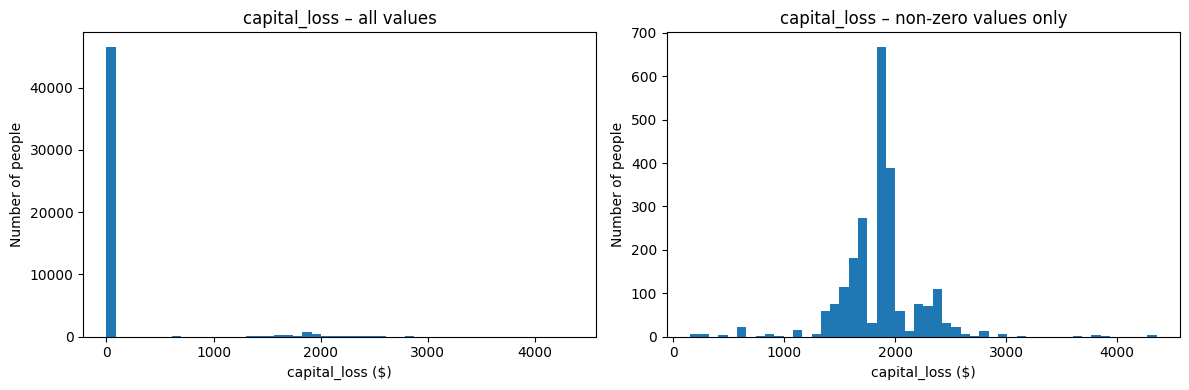

In [13]:
# capital_loss: all values (left) and only the non-zero values (right)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(df["capital_loss"], bins=50)                         # full distribution
ax[0].set_title("capital_loss – all values")
ax[0].set_xlabel("capital_loss ($)"); ax[0].set_ylabel("Number of people")

ax[1].hist(df.loc[df["capital_loss"] > 0, "capital_loss"], bins=50)   # zeros removed
ax[1].set_title("capital_loss – non-zero values only")
ax[1].set_xlabel("capital_loss ($)"); ax[1].set_ylabel("Number of people")

plt.tight_layout()
plt.show()

In [14]:
# Transformation: None (0), Low (up to the median of non-zero values), High (above it)
def to_category(col):
    cut_point = df.loc[df[col] > 0, col].median()            # median of the non-zero values
    return pd.cut(df[col],
                  bins=[-np.inf, 0, cut_point, np.inf],      # (-inf,0] (0,median] (median,inf)
                  labels=["None", "Low", "High"])

df["capital_gain_cat"] = to_category("capital_gain")
df["capital_loss_cat"] = to_category("capital_loss")

# Table: count and % of each category, plus the share earning >50K in each category
def describe_cat(cat_col):
    t = df.groupby(cat_col, observed=True).agg(
        count=("gross_income_group", "size"),
        pct_high_income=("gross_income_group", lambda s: round((s == ">50K").mean() * 100, 1)))
    t["pct_of_people"] = (t["count"] / len(df) * 100).round(2)
    return t[["count", "pct_of_people", "pct_high_income"]]

print("Cut points (median of non-zero values):",
      df.loc[df["capital_gain"] > 0, "capital_gain"].median(), "and",
      df.loc[df["capital_loss"] > 0, "capital_loss"].median())
display(describe_cat("capital_gain_cat"))
display(describe_cat("capital_loss_cat"))

Cut points (median of non-zero values): 7298.0 and 1887.0


,count,pct_of_people,pct_high_income
capital_gain_cat,,,
None,44807,91.74,20.5
Low,2345,4.80,35.4
High,1690,3.46,98.3


,count,pct_of_people,pct_high_income
capital_loss_cat,,,
None,46560,95.33,22.6
Low,1166,2.39,34.1
High,1116,2.28,66.8


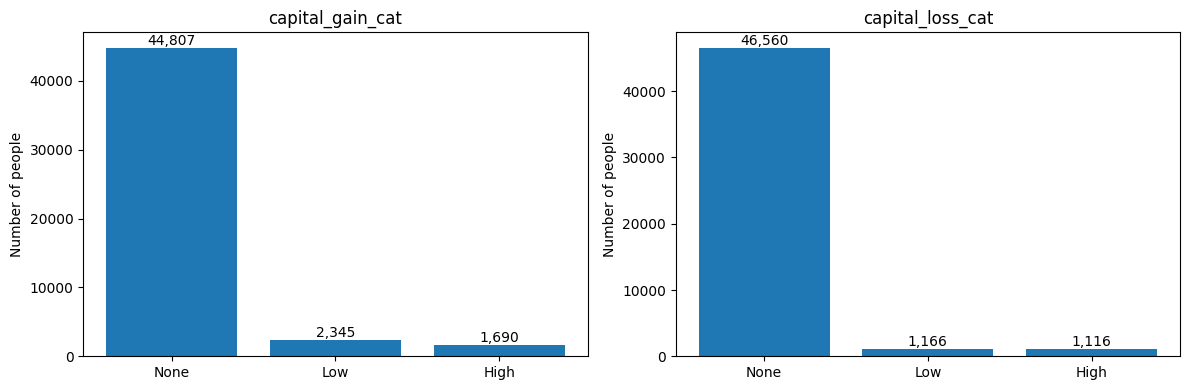

In [15]:
# Bar plots of the new categorical variables
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, col in zip(ax, ["capital_gain_cat", "capital_loss_cat"]):
    counts = df[col].value_counts().reindex(["None", "Low", "High"])   # keep a fixed order
    a.bar(counts.index.astype(str), counts.values)
    a.set_title(col)
    a.set_ylabel("Number of people")
    for i, v in enumerate(counts.values):                              # write the count on each bar
        a.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

**Answer:** Both variables are highly skewed and dominated by zeros. **91.74%** of people have `capital_gain = 0` and **95.33%** have `capital_loss = 0`. Among the non-zero values, `capital_gain` is spread out (median 7,298) with a long right tail (skewness 11.89) and a spike at **99,999** (244 people), which looks like a cap or placeholder value rather than a real amount. The non-zero values of `capital_loss` are concentrated between about 1,500 and 2,000 (median 1,887, maximum 4,356, skewness 4.57).

I think both should be transformed into categorical variables. As numbers, they are almost always zero, and the few extreme values (such as 99,999) would have a large influence on a linear model. The useful information is whether a person had a capital gain or loss and whether it was small or large. I created three categories: **None** (0), **Low** (up to the median of the non-zero values) and **High** (above it), using cut points of 7,298 for gains and 1,887 for losses:

| Category | capital_gain_cat | % | % earning >50K | capital_loss_cat | % | % earning >50K |
|---|---|---|---|---|---|---|
| None | 44,807 | 91.74 | 20.5 | 46,560 | 95.33 | 22.6 |
| Low | 2,345 | 4.80 | 35.4 | 1,166 | 2.39 | 34.1 |
| High | 1,690 | 3.46 | 98.3 | 1,116 | 2.28 | 66.8 |

The categories are meaningful: the share of people earning more than $50K rises clearly from None to Low to High, especially for capital gains (20.5% → 35.4% → 98.3%). The 99,999 values fall in the High group, so the cap no longer distorts the variable.

## Q4. Explore the distribution of fnlwgt. Is it symmetric? Compare men and women. Should outliers be excluded?

In [16]:
# Numeric summary and skewness of fnlwgt
print(df["fnlwgt"].describe().round(0))
print("\nSkewness:", round(df["fnlwgt"].skew(), 2))
print("Skewness of log(fnlwgt):", round(np.log(df["fnlwgt"]).skew(), 2))

count      48842.0
mean      189664.0
std       105604.0
min        12285.0
25%       117550.0
50%       178144.0
75%       237642.0
max      1490400.0
Name: fnlwgt, dtype: float64

Skewness: 1.44
Skewness of log(fnlwgt): -0.84


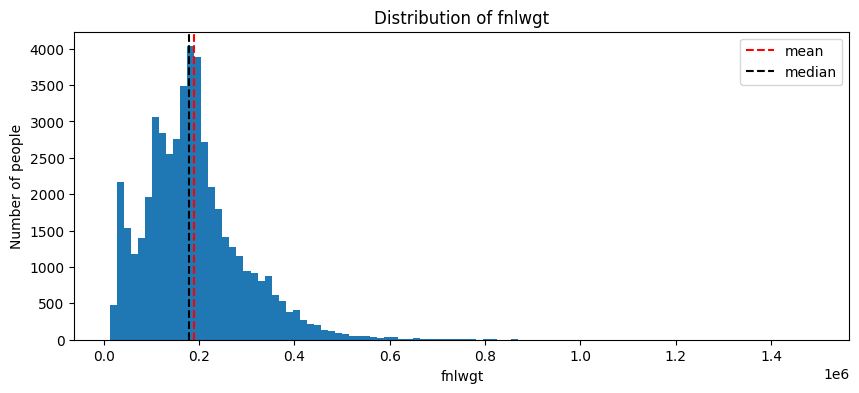

In [17]:
# Distribution of fnlwgt, with the mean and median marked
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df["fnlwgt"], bins=100)
ax.axvline(df["fnlwgt"].mean(), color="red", linestyle="--", label="mean")
ax.axvline(df["fnlwgt"].median(), color="black", linestyle="--", label="median")
ax.set_title("Distribution of fnlwgt")
ax.set_xlabel("fnlwgt"); ax.set_ylabel("Number of people")
ax.legend()
plt.show()

In [18]:
# Compare men and women: summary statistics and skewness
by_sex = df.groupby("sex")["fnlwgt"].describe().round(0)
by_sex["skewness"] = df.groupby("sex")["fnlwgt"].skew().round(2)
display(by_sex)

# Mann-Whitney U test: do the two distributions differ? (does not assume normality)
men = df.loc[df["sex"] == "Male", "fnlwgt"]
women = df.loc[df["sex"] == "Female", "fnlwgt"]
print("Mann-Whitney U p-value:", stats.mannwhitneyu(men, women).pvalue)

,count,mean,std,min,25%,50%,75%,max,skewness
sex,,,,,,,,,
Female,16192.0,185504.0,103217.0,12285.0,116560.0,175572.0,228609.0,1484705.0,1.62
Male,32650.0,191727.0,106709.0,13492.0,117963.0,180138.0,241722.0,1490400.0,1.36


Mann-Whitney U p-value: 8.229101914735855e-10


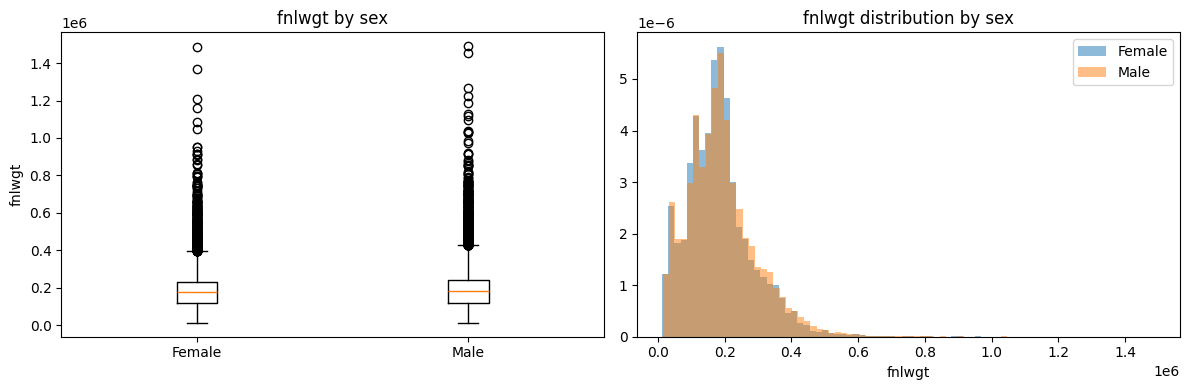

In [19]:
# Box plots and overlaid histograms by sex
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].boxplot([women, men], tick_labels=["Female", "Male"])       # box = middle 50%, dots = outliers
ax[0].set_title("fnlwgt by sex"); ax[0].set_ylabel("fnlwgt")

ax[1].hist(women, bins=80, alpha=0.5, density=True, label="Female")   # density: compare shapes,
ax[1].hist(men, bins=80, alpha=0.5, density=True, label="Male")       # not group sizes
ax[1].set_title("fnlwgt distribution by sex"); ax[1].set_xlabel("fnlwgt")
ax[1].legend()

plt.tight_layout()
plt.show()

In [20]:
# Outliers with the IQR rule: below Q1 - 1.5*IQR or above Q3 + 1.5*IQR
q1, q3 = df["fnlwgt"].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outlier = (df["fnlwgt"] < lower) | (df["fnlwgt"] > upper)

print(f"Lower fence: {lower:,.0f}   Upper fence: {upper:,.0f}")
print(f"Outliers: {outlier.sum():,} rows ({outlier.mean() * 100:.2f}%)")
print("Share of outliers by sex (%):")
print((outlier.groupby(df["sex"]).mean() * 100).round(2))

Lower fence: -62,587   Upper fence: 417,779
Outliers: 1,453 rows (2.97%)
Share of outliers by sex (%):
sex
Female    2.46
Male      3.23
Name: fnlwgt, dtype: float64


In [21]:
# Decision: set outlying fnlwgt values to missing for the rest of the analysis
df.loc[outlier, "fnlwgt"] = np.nan
print("fnlwgt missing after removing outliers:", df["fnlwgt"].isna().sum())
print("New skewness:", round(df["fnlwgt"].skew(), 2))

fnlwgt missing after removing outliers: 1453
New skewness: 0.42


**Answer:** `fnlwgt` is **not symmetric**; it is right-skewed (skewness 1.44). The mean (189,664) is larger than the median (178,144), 75% of the values are below 237,642, but the maximum is 1,490,400, about 8 times the median. Taking the log over-corrects and gives a slight left skew (−0.84).

**Men vs women:** the two distributions have a similar shape and are both right-skewed. Men have slightly higher values (median 180,138 vs 175,572; mean 191,727 vs 185,504), while women's distribution is slightly more skewed (1.62 vs 1.36). The Mann-Whitney U test shows the difference is statistically significant (p ≈ 8 × 10⁻¹⁰), but it is small (about 2.5%), and the significance comes mostly from the large sample size. Men also have a slightly higher share of outliers (3.23% vs 2.46%).

**Outliers:** using the IQR rule, the upper fence is 417,779 (the lower fence is negative, so there are no low outliers). **1,453 rows (2.97%)** are above it. I decided to set these `fnlwgt` values to missing. Since `fnlwgt` is a sampling weight, these few observations would count 2 to 8 times more than a typical respondent in any weighted analysis and could dominate the results. They are only 3% of the rows, so little information is lost, and the skewness drops from 1.44 to 0.42. Only `fnlwgt` is set to missing; the other columns of these rows are kept.

## Q5. Linear regression: hours_per_week (dependent) on sex (independent)

In [22]:
# Mean hours per week by sex, for reference
df.groupby("sex")["hours_per_week"].agg(["mean", "median", "count"]).round(2)

,mean,median,count
sex,,,
Female,36.40,40.0,16192
Male,42.42,40.0,32650


In [23]:
# OLS regression. Female is the reference group, so the Male coefficient is the
# difference in average weekly hours between men and women.
m1 = smf.ols("hours_per_week ~ C(sex, Treatment('Female'))", data=df).fit()
print(m1.summary())

                            OLS Regression Results                            
Dep. Variable:         hours_per_week   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     2692.
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:55:50   Log-Likelihood:            -1.9093e+05
No. Observations:               48842   AIC:                         3.819e+05
Df Residuals:                   48840   BIC:                         3.819e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

**Answer:** The intercept (**36.40**) is the average weekly hours for women, the reference group. The Male coefficient is **6.02** (95% CI 5.79 to 6.24, p < 0.001), so men work on average about **6 more hours per week** than women, and the difference is highly significant. However, R² is only **0.052**: sex explains about 5% of the variation in weekly hours. Both groups have the same median (40 hours), so the gap comes from the rest of the distribution, not the typical full-time week.

## Q6. Adding education_num and gross_income_group, and choosing the best model

In [24]:
# Binary version of income: 1 if >50K, 0 otherwise
df["high_income"] = (df["gross_income_group"] == ">50K").astype(int)

# Model 2: sex + education_num (education as a control variable)
m2 = smf.ols("hours_per_week ~ C(sex, Treatment('Female')) + education_num", data=df).fit()

# Model 3: sex + education_num + income group
m3 = smf.ols("hours_per_week ~ C(sex, Treatment('Female')) + education_num + high_income", data=df).fit()

print(m2.summary())

                            OLS Regression Results                            
Dep. Variable:         hours_per_week   R-squared:                       0.072
Model:                            OLS   Adj. R-squared:                  0.072
Method:                 Least Squares   F-statistic:                     1903.
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:55:51   Log-Likelihood:            -1.9041e+05
No. Observations:               48842   AIC:                         3.808e+05
Df Residuals:                   48839   BIC:                         3.808e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

In [25]:
print(m3.summary())

                            OLS Regression Results                            
Dep. Variable:         hours_per_week   R-squared:                       0.093
Model:                            OLS   Adj. R-squared:                  0.093
Method:                 Least Squares   F-statistic:                     1666.
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:55:51   Log-Likelihood:            -1.8986e+05
No. Observations:               48842   AIC:                         3.797e+05
Df Residuals:                   48838   BIC:                         3.798e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

In [26]:
# Side-by-side comparison of the three models
models = {"Model 1: sex": m1,
          "Model 2: sex + education": m2,
          "Model 3: sex + education + income": m3}

rows = []
for name, m in models.items():
    rows.append({
        "model": name,
        "Male coef": round(m.params["C(sex, Treatment('Female'))[T.Male]"], 3),
        "education_num coef": round(m.params.get("education_num", np.nan), 3),
        "high_income coef": round(m.params.get("high_income", np.nan), 3),
        "R2": round(m.rsquared, 4),
        "Adj. R2": round(m.rsquared_adj, 4),       # R2 penalised for extra variables
        "AIC": round(m.aic, 1),                     # lower is better
        "BIC": round(m.bic, 1),                     # lower is better, stronger penalty
        "n": int(m.nobs),
    })
comparison = pd.DataFrame(rows).set_index("model")
comparison

,Male coef,education_num coef,high_income coef,R2,Adj. R2,AIC,BIC,n
model,,,,,,,,
Model 1: sex,6.016,NaN,NaN,0.0522,0.0522,381861.3,381878.9,48842
Model 2: sex + education,5.981,0.682,NaN,0.0723,0.0722,380819.5,380845.8,48842
Model 3: sex + education + income,5.112,0.434,4.533,0.0929,0.0928,379726.0,379761.2,48842


In [27]:
# F-test for nested models: does each added variable significantly improve the fit?
anova_lm(m1, m2, m3)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,48840.0,7.107665e+06,0.0,NaN,NaN,NaN
1,48839.0,6.957376e+06,1.0,150289.368770,1078.899628,4.570432e-234
2,48838.0,6.803072e+06,1.0,154303.361246,1107.715339,3.421204e-240


In [28]:
# Robustness check: Model 1 weighted by the sampling weights (outliers already set to NaN)
d = df.dropna(subset=["fnlwgt"])
m1_w = smf.wls("hours_per_week ~ C(sex, Treatment('Female'))", data=d, weights=d["fnlwgt"]).fit()
print("Weighted Male coefficient:", round(m1_w.params["C(sex, Treatment('Female'))[T.Male]"], 3),
      "| n =", int(m1_w.nobs))

Weighted Male coefficient: 5.798 | n = 47389


**Answer:** **a) Who works more hours?** Men, by about 6 hours per week (42.4 vs 36.4 on average).

**b) Controlling for education_num:** the Male coefficient changes only from 6.02 to **5.98**, so the gap between men and women stays almost the same and is not explained by education. `education_num` is significant: each additional education level is associated with about **0.68** more hours per week (t = 32.5, p < 0.001).

**c) Adding gross_income_group** (`high_income` = 1 if >50K): the Male coefficient drops to **5.11**, education to **0.43**, and people earning more than $50K work about **4.53** more hours per week. All coefficients are significant (p < 0.001). About 0.9 hours of the gender gap is associated with income differences.

| Model | R² | Adj. R² | AIC | BIC |
|---|---|---|---|---|
| 1: sex | 0.0522 | 0.0522 | 381,861 | 381,879 |
| 2: + education_num | 0.0723 | 0.0722 | 380,820 | 380,846 |
| 3: + high_income | 0.0929 | 0.0928 | 379,726 | 379,761 |

**Which statistic to choose:** plain R² is not a good choice, because it always increases when a variable is added. I would use **adjusted R²** (or AIC/BIC), which penalises extra variables. Because the models are nested, the **F-test** (`anova_lm`) can also test whether each added variable improves the fit. All of these agree: adjusted R² increases, AIC and BIC decrease, and both F-tests have p < 0.001, so **Model 3 is the best**.

Two limitations: all models explain less than 10% of the variation in hours, and income is partly a *result* of working more hours, so Model 3 shows associations, not causes. As a check, weighting Model 1 by `fnlwgt` gives a similar gap (5.80 hours).

# Correlation
Correlations between `age`, `education_num` and `hours_per_week`.

## Q1. Do any of the variables appear to be correlated? How did you make your assessment?

In [29]:
# Pearson correlation matrix (measures linear relationships, from -1 to +1)
num_vars = ["age", "education_num", "hours_per_week"]
pearson = df[num_vars].corr(method="pearson").round(4)
pearson

,age,education_num,hours_per_week
age,1.0000,0.0309,0.0716
education_num,0.0309,1.0000,0.1437
hours_per_week,0.0716,0.1437,1.0000


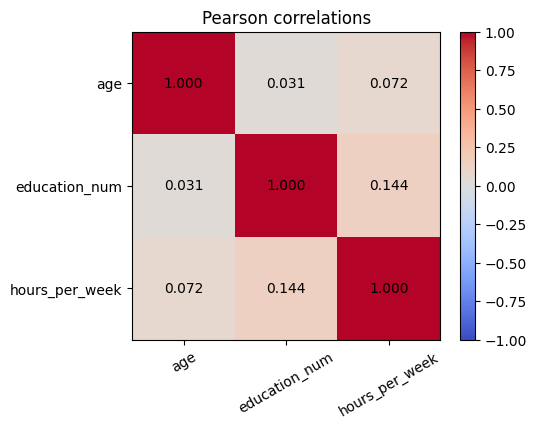

In [30]:
# Heatmap of the Pearson correlation matrix
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(pearson, cmap="coolwarm", vmin=-1, vmax=1)     # colour scale fixed from -1 to +1
ax.set_xticks(range(3)); ax.set_xticklabels(num_vars, rotation=30)
ax.set_yticks(range(3)); ax.set_yticklabels(num_vars)
for i in range(3):                                              # write each value in its square
    for j in range(3):
        ax.text(j, i, f"{pearson.iloc[i, j]:.3f}", ha="center", va="center")
fig.colorbar(im)
ax.set_title("Pearson correlations")
plt.show()

In [31]:
# Spearman correlation (based on ranks): also picks up relationships that are not straight lines
df[num_vars].corr(method="spearman").round(4)

,age,education_num,hours_per_week
age,1.0000,0.0632,0.1466
education_num,0.0632,1.0000,0.1644
hours_per_week,0.1466,0.1644,1.0000


In [32]:
# Average hours and education by age group, to see the shape of the age relationships
age_groups = pd.cut(df["age"], bins=[16, 25, 35, 45, 55, 65, 91])
df.groupby(age_groups, observed=True)[["hours_per_week", "education_num"]].mean().round(2)

,hours_per_week,education_num
age,,
"(16, 25]",33.80,9.42
"(25, 35]",42.46,10.26
"(35, 45]",43.50,10.54
"(45, 55]",43.24,10.28
"(55, 65]",40.05,9.67
"(65, 91]",28.92,9.33


**Answer:** I assessed the correlations with the Pearson correlation matrix and heatmap, using the common rule of thumb that |r| < 0.1 is negligible, 0.1 to 0.3 is weak, 0.3 to 0.5 is moderate and above 0.5 is strong. Only **education_num and hours_per_week** show a (weak) positive correlation, **r = 0.144**. The other two pairs are negligible: age and hours_per_week r = 0.072, and age and education_num r = 0.031.

However, the Spearman correlation between age and hours_per_week is higher (**0.147**), which means the relationship is not a straight line. The age-group table shows an inverted U: people work about 34 hours at ages 17 to 25, about 43 to 44 hours between 26 and 55, and only about 29 hours after 65. Pearson's r measures only linear relationships, so it underestimates this pattern. Education follows a similar but much flatter inverted U with age.

## Q2. Statistically test pairs with |r| > 0.1 for difference from 0. Is the direction and significance as expected?

In [33]:
# Pearson test for every pair: r, p-value (H0: r = 0) and 95% confidence interval
from itertools import combinations

rows = []
for x, y in combinations(num_vars, 2):
    res = stats.pearsonr(df[x], df[y])
    ci = res.confidence_interval()
    rows.append({"pair": f"{x} – {y}",
                 "r": round(res.statistic, 4),
                 "p_value": res.pvalue,
                 "95% CI": f"[{ci.low:.3f}, {ci.high:.3f}]",
                 "|r| > 0.1": abs(res.statistic) > 0.1})
tests = pd.DataFrame(rows).set_index("pair")
tests

,r,p_value,95% CI,|r| > 0.1
pair,,,,
age – education_num,0.0309,7.955033e-12,"[0.022, 0.040]",False
age – hours_per_week,0.0716,1.800240e-56,"[0.063, 0.080]",False
education_num – hours_per_week,0.1437,1.386029e-223,"[0.135, 0.152]",True


**Answer:** Only one pair has |r| > 0.1: **education_num and hours_per_week**, with r = 0.144, 95% CI [0.135, 0.152] and p ≈ 1.4 × 10⁻²²³. The null hypothesis (r = 0) is rejected, so there is a significant positive correlation.

The direction is as expected: people with more education more often work in professional and managerial jobs, which tend to have longer hours, while part-time work is more common in less-educated jobs. The weak strength is also expected, because weekly hours depend on many other factors and most people work a standard 40-hour week.

With 48,842 observations, even very small correlations are significant: the other two pairs also have p < 0.001, although they are negligible in size. Statistical significance here says the correlation is not zero, not that it is strong.

## Q3. How does the correlation between education_num and age compare between men and women?

In [34]:
# Correlation between education_num and age, separately for men and women
rows = []
for sex in ["Male", "Female"]:
    d = df[df["sex"] == sex]
    res = stats.pearsonr(d["education_num"], d["age"])
    ci = res.confidence_interval()
    rows.append({"sex": sex, "n": len(d),
                 "r": round(res.statistic, 4),
                 "p_value": res.pvalue,
                 "95% CI": f"[{ci.low:.3f}, {ci.high:.3f}]"})
by_sex_corr = pd.DataFrame(rows).set_index("sex")
by_sex_corr

,n,r,p_value,95% CI
sex,,,,
Male,32650,0.0541,1.404591e-22,"[0.043, 0.065]"
Female,16192,-0.0205,9.162998e-03,"[-0.036, -0.005]"


In [35]:
# Fisher z-test: are the two correlations significantly different from each other?
r_m, n_m = by_sex_corr.loc["Male", "r"], by_sex_corr.loc["Male", "n"]
r_f, n_f = by_sex_corr.loc["Female", "r"], by_sex_corr.loc["Female", "n"]

z = (np.arctanh(r_m) - np.arctanh(r_f)) / np.sqrt(1 / (n_m - 3) + 1 / (n_f - 3))   # difference in z-units
p = 2 * stats.norm.sf(abs(z))                                                        # two-sided p-value
print(f"Fisher z = {z:.2f}, p-value = {p:.2e}")

Fisher z = 7.77, p-value = 8.07e-15


In [36]:
# Average education by age group for each sex, to see where the difference comes from
df.pivot_table(index=age_groups, columns="sex", values="education_num",
               aggfunc="mean", observed=True).round(2)

sex,Female,Male
age,,
"(16, 25]",9.65,9.23
"(25, 35]",10.42,10.18
"(35, 45]",10.50,10.56
"(45, 55]",10.05,10.37
"(55, 65]",9.42,9.77
"(65, 91]",8.98,9.49


**Answer:** The correlation between education_num and age is very weak in both groups, but in **opposite directions**: for men **r = 0.054** (p ≈ 1.4 × 10⁻²²) and for women **r = −0.021** (p ≈ 0.009). Both are significant because the samples are large. The Fisher z-test shows the two correlations are significantly different from each other (z = 7.77, p ≈ 8 × 10⁻¹⁵).

The age-group table explains the difference. Among younger people (17 to 35), women have slightly more education than men (e.g. 10.42 vs 10.18 at ages 26 to 35), while among older people (45 and over) women have less (8.98 vs 9.49 after 65). So for women, education tends to fall with age, and for men it tends to rise slightly.

This is expected given the historical context: in 1994, older women had grown up when fewer women continued their education, and women's education increased faster across generations than men's. The effect sizes are very small, though, and for both sexes education peaks around ages 35 to 45, so a single linear correlation does not describe the relationship well.

## Q4. Covariance matrix for education_num and hours_per_week

In [37]:
# Covariance matrix: variances on the diagonal, covariance off the diagonal
cov = df[["education_num", "hours_per_week"]].cov()
print(cov.round(3))

# Dividing the covariance by both standard deviations gives back the correlation
sd = df[["education_num", "hours_per_week"]].std()
print("\nStandard deviations:\n", sd.round(3))
print("\nCovariance / (sd_edu * sd_hours) =",
      round(cov.loc["education_num", "hours_per_week"] / (sd["education_num"] * sd["hours_per_week"]), 4))

                education_num  hours_per_week
education_num           6.610           4.578
hours_per_week          4.578         153.548

Standard deviations:
 education_num      2.571
hours_per_week    12.391
dtype: float64

Covariance / (sd_edu * sd_hours) = 0.1437


**Answer:** The covariance matrix gives:
- Variance of education_num = **6.61** (standard deviation 2.57 levels)
- Variance of hours_per_week = **153.55** (standard deviation 12.39 hours)
- Covariance = **4.58**

The positive covariance means that people with above-average education tend to also work above-average hours. However, the size of the covariance cannot be used to judge the strength of the relationship, because it depends on the units of the two variables; hours per week simply varies much more than education. Dividing the covariance by both standard deviations gives 4.578 / (2.571 × 12.391) = **0.144**, which is exactly the Pearson correlation: a weak positive relationship, consistent with Q1 and Q2.

The covariance also links to the regression: the slope of hours_per_week on education_num alone is covariance / variance of education = 4.578 / 6.61 ≈ **0.69 hours per education level**, very close to the 0.68 found in Model 2.